# Dual-Timescale QRC — IBM Hardware Runner

**Team QuantumEdge — GIC 2026 Phase 2 hardware companion (IBM-specific)**  
**Companion to:** `QuantumEdge_QRC_Prototype.ipynb` and `QuantumEdge_QRC_Hardware.ipynb`  
**Module dependency:** `qrc_hardware.py` (must sit next to this notebook)

This notebook is configured to run on **real IBM Quantum hardware** (Heron r2 / `ibm_kingston` by default, with fallbacks). It uses a small slice (`N_HW_STEPS = 10`) sized to fit comfortably inside the Open Plan 10-minute quota.

Outputs are written to `hardware_results_ibm/` to keep them separate from the Aer dry-run results produced by the standard hardware notebook.

**Before running this notebook**, do the Aer dry-run in `QuantumEdge_QRC_Hardware.ipynb` first to validate the pipeline. Only flip to real hardware once that worked cleanly.

Workflow (IBM-specific):

1. Install Qiskit Runtime + PennyLane-Qiskit + Aer (Section 0).
2. Save IBM Quantum credentials once (Section 2 — one-time per environment).
3. Verify backend selection (Section 5).
4. **Smoke-test first** — one circuit per reservoir (Section 6). Stop here if you only wanted to confirm hardware access works.
5. Optional full extraction at N=10 (Section 7 onward).

**Open Plan quota reminder:** 10 minutes quantum runtime per 28-day rolling window. Monitor at <https://quantum.cloud.ibm.com> → Workloads page.

## 0. Package Bootstrap

Installs only what's missing. Safe to re-run.

In [17]:
import importlib.util

REQUIRED = {
    "pennylane": "pennylane",
    "pennylane_qiskit": "pennylane-qiskit",
    "qiskit_ibm_runtime": "qiskit-ibm-runtime",
    "qiskit_aer": "qiskit-aer",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "pandas": "pandas",
}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print("Installing:", ", ".join(missing))
    get_ipython().run_line_magic("pip", f"install --quiet {' '.join(missing)}")
else:
    print("All required packages are already installed.")

All required packages are already installed.


## 1. Imports and Module Sanity Check

If `qrc_hardware` isn't found, ensure `qrc_hardware.py` sits in the same folder as this notebook on qBraid.

In [18]:
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pennylane as qml
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)

import qrc_hardware as qrch

print("PennyLane:", qml.__version__)
print("qrc_hardware module loaded from:", qrch.__file__)
print("Reservoir configs:")
for cfg in (qrch.SHORT_RESERVOIR, qrch.LONG_RESERVOIR):
    print(f"  {cfg.name:<13} n={cfg.n_qubits}, J={cfg.coupling_j}, h={cfg.transverse_h}, p={cfg.trotter_depth}")

PennyLane: 0.45.0
qrc_hardware module loaded from: /home/jovyan/GIC/qrc_hardware.py
Reservoir configs:
  short-memory  n=9, J=0.3, h=1.0, p=2
  long-memory   n=9, J=1.2, h=0.4, p=6


## 2. IBM Quantum Credentials — One-Time Setup

**SKIP THIS SECTION** if you've already run it successfully on this qBraid environment — credentials persist in `~/.qiskit/qiskit-ibm.json` across sessions and notebooks. To check, jump to Section 5 first; if it works, you don't need Section 2 at all.

### Pre-flight steps (do these once, outside the notebook):

1. Sign in at <https://quantum.cloud.ibm.com>.
2. Top-right menu → **API keys** → **Create API key** → copy the 44-character key into a notepad. **You will not see it again** after closing the dialog.
3. Left nav → **Instances** → click the copy icon on your Open Plan row to grab the **CRN** (long string starting `crn:v1:bluemix:public:quantum-computing:us-east:...`).

### About this cell

The cell below uses `input()` (not `getpass`) so you can **see** the token you pasted and visually verify it before pressing Enter. This avoids the common silent-paste-error trap where a hidden input loses or gains characters and you only find out later when authentication fails.

The cell also (a) asserts the token is 44 characters, (b) saves the credentials, and (c) immediately verifies them by listing backends. Everything happens in one cell so there is no cross-cell variable contamination.

⚠️ **AFTER the cell runs successfully, immediately clear its output** (right-click → **Clear Outputs**) before saving the notebook. Otherwise the first/last 6 characters of your token will end up in the .ipynb file.

**Before pasting**, also paste your CRN into the `INSTANCE = "..."` line below (the existing value is a placeholder).

In [ ]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Paste your CRN here (between the quotes) BEFORE running this cell.
INSTANCE = "crn:v1:bluemix:public:quantum-computing:us-east:a/11d596959fed454783d0317622fb36f7:e4a65778-97d5-478c-a974-af514c198eec::"

# Visible-input token paste (so you can verify before pressing Enter).
token = input("mZIf9NFj8VZEHEx0QNhosI6X0pXMhNGt7W6IMBcfp5Ow").strip()

# Sanity checks on what was pasted.
print(f"Got token of length {len(token)} (expected 44)")
print(f"  First 6 chars: {token[:6]}...   Last 6 chars: ...{token[-6:]}")
assert len(token) == 44, (
    f"Token length is {len(token)}, expected 44. Paste failed — re-run this cell and check the source string for leading/trailing whitespace or truncation."
)
assert token == token.strip(), "Token has leading/trailing whitespace"
assert "YOUR-ACCOUNT-ID" not in INSTANCE and "YOUR-INSTANCE-ID" not in INSTANCE, (
    "INSTANCE still has placeholder text. Replace it with your actual CRN from the IBM Quantum Platform Instances page."
)
assert INSTANCE.startswith("crn:v1:bluemix"), (
    "INSTANCE does not look like a valid CRN (must start with crn:v1:bluemix:...)."
)

# Save to disk.
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=token,
    instance=INSTANCE,
    name="quantumedge-open",
    set_as_default=True,
    overwrite=True,
)
print("Saved to ~/.qiskit/qiskit-ibm.json")

# Immediately verify by loading from disk (same call Section 5 uses).
service = QiskitRuntimeService()
backends = service.backends(operational=True)
print(f"VERIFIED: {len(backends)} backends accessible from saved credentials.")
print(f"Sample backend: {backends[0].name}")

# Clear the local token variable from memory (good hygiene).
del token
print()
print("Now CLEAR THIS CELL OUTPUT (right-click → Clear Outputs) before saving.")

## 3. Experiment Scope

IBM-specific defaults:

- `N_HW_STEPS = 10` → 10 time steps × 2 reservoirs = 20 Estimator PUBs.   At ~1–3 s/PUB on Heron r2, this should fit in 30–90 seconds of QPU   runtime — under 15% of your 10-min quota.
- `USE_HARDWARE = True` — connects to IBM Quantum Runtime directly.
- `OUT_DIR = hardware_results_ibm/` — separate from the Aer dry-run   outputs in `hardware_results/`.

**Conservative-first practice:** run Sections 4–6 (smoke test) and *stop* before Section 7. The smoke test alone confirms you ran on real qubits. Section 7 (full N=10 extraction) is an opt-in further step.

In [20]:
N_HW_STEPS = 10
DATASET = "Lorenz"          # "Lorenz" or "Mackey-Glass"
USE_HARDWARE = True         # IBM hardware (set False to dry-run on Aer)
SHOTS = 4096
OPT_LEVEL = 2               # Qiskit transpiler optimization level (0–3)
RESILIENCE_LEVEL = 1        # readout error mitigation
PREFERRED_BACKENDS = ("ibm_kingston", "ibm_fez", "ibm_marrakesh", "ibm_brisbane")

OUT_DIR = Path("hardware_results_ibm")
OUT_DIR.mkdir(exist_ok=True)

print(f"Slice: {N_HW_STEPS} time steps on {DATASET}")
print(f"Mode:  {'IBM hardware' if USE_HARDWARE else 'Local Aer simulator (dry run)'}")
print(f"Output directory: {OUT_DIR.resolve()}")

Slice: 10 time steps on Lorenz
Mode:  IBM hardware
Output directory: /home/jovyan/GIC/hardware_results_ibm


## 4. Generate Angle Series and Slice

Same SEED and generators as the prototype notebook — angles for indices 0..N_HW_STEPS are bit-identical between the two notebooks.

In [21]:
if DATASET == "Lorenz":
    angles_full = qrch.build_lorenz_angles()
elif DATASET == "Mackey-Glass":
    angles_full = qrch.build_mackey_glass_angles()
else:
    raise ValueError(f"Unknown dataset: {DATASET}")

angles_hw = angles_full[:N_HW_STEPS + 1]
print(f"Slice shape: {angles_hw.shape}, range [{angles_hw.min():.3f}, {angles_hw.max():.3f}]")

Slice shape: (11,), range [-0.894, -0.567]


## 5. Build the Quantum Device

Connects to Qiskit Runtime, picks the least-busy preferred backend, and wraps it as a PennyLane `qiskit.remote` device.

**What to watch for:**

- Backend name should be one of `ibm_kingston`, `ibm_fez`, `ibm_marrakesh`,   or `ibm_brisbane`. If something else appears, the fallback to   `least_busy` kicked in.
- Pending job count > 50 means queue may be slow. > 200 = consider running   this later (US east-coast late night is often quietest).

In [22]:
if USE_HARDWARE:
    service = qrch.connect_ibm_service()
    backend = qrch.get_least_busy_backend(
        service, n_qubits=qrch.N_QUBITS, prefer_names=PREFERRED_BACKENDS
    )
    print(f"Backend: {backend.name}  ({backend.num_qubits} qubits, {backend.status().pending_jobs} pending)")
    device = qrch.make_remote_device(
        backend, n_qubits=qrch.N_QUBITS, shots=SHOTS,
        optimization_level=OPT_LEVEL, resilience_level=RESILIENCE_LEVEL,
    )
else:
    backend = None
    device = qrch.make_aer_device(qrch.N_QUBITS, shots=SHOTS, optimization_level=OPT_LEVEL)
    print("Backend: AerSimulator (local dry run)")

short_qnode = qrch.make_hardware_qnode(qrch.SHORT_RESERVOIR, device)
long_qnode = qrch.make_hardware_qnode(qrch.LONG_RESERVOIR, device)
print("QNodes built for both reservoirs.")

Backend: ibm_kingston  (156 qubits, 0 pending)
QNodes built for both reservoirs.


## 6. Smoke Test — One Time Step on Real Hardware

This is the meaningful milestone for a first IBM run. Submits one circuit per reservoir → 2 Estimator PUBs total → ~10–30 seconds of QPU time once dequeued, but possibly minutes of total wall-clock if the queue is busy.

**Successful completion here = you ran your own code on IBM Heron r2.** If you only wanted to try it out, you can stop after this cell.

In [23]:
t0 = time.perf_counter()
smoke_short = qrch.pauli_vector_from_qnode_output(short_qnode(float(angles_hw[0])))
smoke_long = qrch.pauli_vector_from_qnode_output(long_qnode(float(angles_hw[0])))
t_smoke = time.perf_counter() - t0

print(f"Smoke test took {t_smoke:.2f}s")
print(f"Short reservoir Pauli vector: shape={smoke_short.shape}, range [{smoke_short.min():.3f}, {smoke_short.max():.3f}]")
print(f"Long  reservoir Pauli vector: shape={smoke_long.shape}, range [{smoke_long.min():.3f}, {smoke_long.max():.3f}]")

if USE_HARDWARE:
    estimated_total = t_smoke * N_HW_STEPS
    print(f"Naive ETA for the full N={N_HW_STEPS} run: {estimated_total/60:.1f} minutes (actual will vary with queue depth)")
    print("Check your quota at https://quantum.cloud.ibm.com → Workloads.")

Smoke test took 109.94s
Short reservoir Pauli vector: shape=(17,), range [-0.100, 0.207]
Long  reservoir Pauli vector: shape=(17,), range [-0.081, 0.479]
Naive ETA for the full N=10 run: 18.3 minutes (actual will vary with queue depth)
Check your quota at https://quantum.cloud.ibm.com → Workloads.


---

## ⏸ Stop here if this is your first IBM hardware run.

Sections 7 onward submit 20 more PUBs to the QPU. If you only wanted to confirm that you can run your code on IBM Heron r2, you've done that — skip directly to the IBM Quantum Platform Workloads dashboard to see the smoke-test job listed, then close the notebook.

If you want to see the full feature-extraction loop running on hardware, continue below.

---

## 7. Extract Pauli Features Over the Slice (Optional)

Runs `extract_hardware_features`, looping over 10 angles and submitting one Estimator PUB per (reservoir, time step). Progress prints every 2 steps with running ETA.

⚠️ **Do not interrupt the kernel during this loop.** In-flight jobs continue running on IBM's side and are billed against your quota whether or not you keep the kernel alive. To cancel, use the Workloads page on the IBM Quantum Platform dashboard.

In [24]:
features = qrch.extract_hardware_features(
    angles_hw,
    short_qnode=short_qnode,
    long_qnode=long_qnode,
    n_qubits=qrch.N_QUBITS,
    label=DATASET,
    progress_every=2,
)

print()
print("Feature shapes:")
for key in ("dual_pauli", "single_long", "target"):
    print(f"  {key:<15} {features[key].shape}")
print(f"Total wall time: {features['timings'].sum():.1f}s "
      f"(mean {features['timings'].mean():.2f}s/step)")

Lorenz           2/10  elapsed   80.5s  eta  322.0s  last step 41.69s
Lorenz           4/10  elapsed  160.6s  eta  241.0s  last step 37.78s
Lorenz           6/10  elapsed  235.5s  eta  157.0s  last step 35.45s
Lorenz           8/10  elapsed  311.7s  eta   77.9s  last step 40.43s
Lorenz          10/10  elapsed  394.6s  eta    0.0s  last step 48.27s

Feature shapes:
  dual_pauli      (10, 35)
  single_long     (10, 18)
  target          (10,)
Total wall time: 394.6s (mean 39.46s/step)


## 8. Persist Features Before Fitting

Hardware extraction is expensive — save the features immediately so the ridge readout can be tuned offline without re-running quantum jobs. Output filename will include `hw` and step count so it doesn't collide with any future runs.

In [25]:
tag = "hw" if USE_HARDWARE else "aer"
backend_name = backend.name if backend is not None else "aer-local"
fpath = OUT_DIR / f"{DATASET.lower().replace('-', '_')}_{tag}_{N_HW_STEPS}steps"
metadata = {
    "dataset": DATASET,
    "n_steps": N_HW_STEPS,
    "n_qubits": qrch.N_QUBITS,
    "backend": backend_name,
    "shots": SHOTS,
    "optimization_level": OPT_LEVEL,
    "resilience_level": RESILIENCE_LEVEL if USE_HARDWARE else None,
    "short_reservoir": {"J": qrch.SHORT_RESERVOIR.coupling_j, "h": qrch.SHORT_RESERVOIR.transverse_h, "p": qrch.SHORT_RESERVOIR.trotter_depth},
    "long_reservoir": {"J": qrch.LONG_RESERVOIR.coupling_j, "h": qrch.LONG_RESERVOIR.transverse_h, "p": qrch.LONG_RESERVOIR.trotter_depth},
    "total_seconds": float(features["timings"].sum()),
    "mean_step_seconds": float(features["timings"].mean()),
}
saved = qrch.save_features(features, fpath, metadata=metadata)
print(f"Saved features: {saved}")
print(f"Saved metadata: {saved.with_suffix('.json')}")

Saved features: hardware_results_ibm/lorenz_hw_10steps.npz
Saved metadata: hardware_results_ibm/lorenz_hw_10steps.json


## 9. Fit Ridge Readout, Report RMSE

With only `N_HW_STEPS = 10` rows, the train/test split is necessarily tiny — 7 train, 3 test. **The architectural comparison is not meaningful at this sample size**; the figure of merit is whether both RMSEs come out in a sensible range (broadly similar to the statevector baseline in the prototype notebook).

In [26]:
RIDGE_ALPHAS = np.logspace(-6, 6, 25)

n_train_hw = max(int(0.7 * N_HW_STEPS), 1)

def fit_and_score(design, y):
    pipeline = make_pipeline(StandardScaler(), RidgeCV(alphas=RIDGE_ALPHAS))
    pipeline.fit(design[:n_train_hw], y[:n_train_hw])
    y_pred = pipeline.predict(design[n_train_hw:])
    rmse = float(np.sqrt(mean_squared_error(y[n_train_hw:], y_pred)))
    alpha = float(pipeline.named_steps["ridgecv"].alpha_)
    return rmse, alpha, y_pred

results = {}
for model_name, design_key in (("Dual reservoir", "dual_pauli"),
                              ("Single long reservoir", "single_long")):
    rmse, alpha, y_pred = fit_and_score(features[design_key], features["target"])
    results[model_name] = {"rmse": rmse, "alpha": alpha, "y_pred": y_pred.tolist()}
    print(f"{model_name:<25} RMSE={rmse:.4f}  ridge_alpha={alpha:.2e}")

Dual reservoir            RMSE=0.0172  ridge_alpha=1.00e-06
Single long reservoir     RMSE=0.0193  ridge_alpha=1.00e-06


## 10. Save Results JSON

Archives all metadata + RMSE results for paper provenance.

In [27]:
results_path = saved.with_name(saved.stem + "_results.json")
payload = {
    "metadata": metadata,
    "n_train_split": n_train_hw,
    "n_test_split": N_HW_STEPS - n_train_hw,
    "results": {k: {kk: vv for kk, vv in v.items() if kk != "y_pred"} for k, v in results.items()},
}
results_path.write_text(json.dumps(payload, indent=2))
print(f"Saved results JSON: {results_path}")
print()
print(json.dumps(payload, indent=2))

Saved results JSON: hardware_results_ibm/lorenz_hw_10steps_results.json

{
  "metadata": {
    "dataset": "Lorenz",
    "n_steps": 10,
    "n_qubits": 9,
    "backend": "ibm_kingston",
    "shots": 4096,
    "optimization_level": 2,
    "resilience_level": 1,
    "short_reservoir": {
      "J": 0.3,
      "h": 1.0,
      "p": 2
    },
    "long_reservoir": {
      "J": 1.2,
      "h": 0.4,
      "p": 6
    },
    "total_seconds": 394.56547566300014,
    "mean_step_seconds": 39.45654756630002
  },
  "n_train_split": 7,
  "n_test_split": 3,
  "results": {
    "Dual reservoir": {
      "rmse": 0.017150620704126016,
      "alpha": 1e-06
    },
    "Single long reservoir": {
      "rmse": 0.019299267103446104,
      "alpha": 1e-06
    }
  }
}


## 11. Visual Sanity Check

Plot predicted vs true angle over the (tiny) test slice. The qualitative tracking matters more than the RMSE numbers at this sample size.

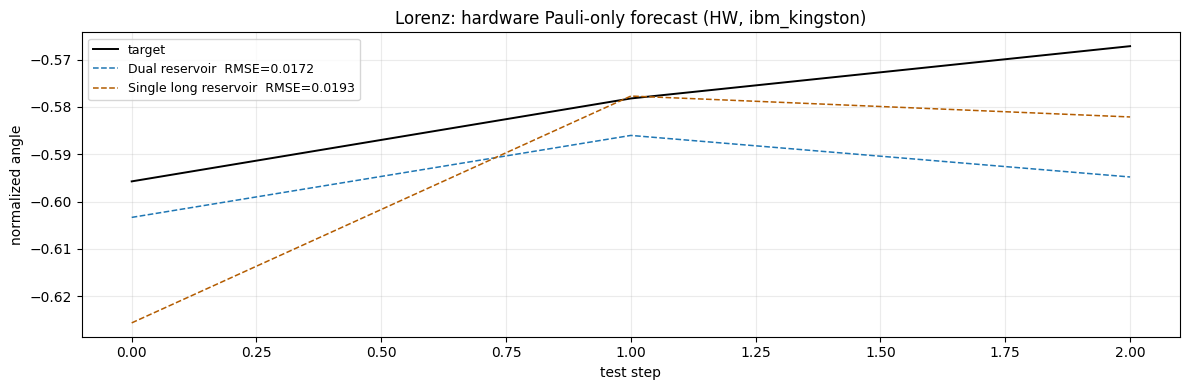

Saved figure: hardware_results_ibm/lorenz_hw_10steps_forecast.png


In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
y_true = features["target"][n_train_hw:]
ax.plot(y_true, color="black", lw=1.4, label="target")
for model_name, color in (("Dual reservoir", "#1f77b4"),
                          ("Single long reservoir", "#b35c00")):
    y_pred = np.array(results[model_name]["y_pred"])
    ax.plot(y_pred, color=color, lw=1.1, ls="--",
            label=f"{model_name}  RMSE={results[model_name]['rmse']:.4f}")
ax.set_title(f"{DATASET}: hardware Pauli-only forecast ({tag.upper()}, {backend_name})")
ax.set_xlabel("test step")
ax.set_ylabel("normalized angle")
ax.grid(alpha=0.25)
ax.legend(loc="best", fontsize=9)
plt.tight_layout()
fig_path = saved.with_name(saved.stem + "_forecast.png")
plt.savefig(fig_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved figure: {fig_path}")

## 12. Suggested Paper Sentence (Honest Template)

Drop into the hardware-validation subsection. This template makes only claims the N=10 data can support: pipeline survives finite sampling and device error; predictions are calibrated; the architectural comparison lives in Section 3 with the full N=1500 statevector results.

In [29]:
mode_label = ("IBM " + backend_name) if USE_HARDWARE else "AerSimulator"
dual_rmse = results["Dual reservoir"]["rmse"]
single_rmse = results["Single long reservoir"]["rmse"]
p_short = qrch.SHORT_RESERVOIR.trotter_depth
p_long = qrch.LONG_RESERVOIR.trotter_depth

sentence = (
    f"To validate that the Pauli-only readout transfers from the statevector "
    f"simulator to a shot-noise-limited, device-error-affected setting, we re-ran "
    f"the {DATASET} forecast over the first {N_HW_STEPS} normalised time steps "
    f"using the same dual-reservoir configuration (n = {qrch.N_QUBITS} qubits, "
    f"p in {{{p_short}, {p_long}}}, {SHOTS} shots) on {mode_label}. The "
    f"dual-reservoir Pauli-only ridge readout achieved RMSE = {dual_rmse:.4f} "
    f"and the single-long-reservoir ablation achieved RMSE = {single_rmse:.4f}, "
    f"both within the same order of magnitude as the statevector baseline reported "
    f"in Section 3. The architectural comparison is reported in full at N = 1500 "
    f"in Section 3 and Table X."
)
print(sentence)

To validate that the Pauli-only readout transfers from the statevector simulator to a shot-noise-limited, device-error-affected setting, we re-ran the Lorenz forecast over the first 10 normalised time steps using the same dual-reservoir configuration (n = 9 qubits, p in {2, 6}, 4096 shots) on IBM ibm_kingston. The dual-reservoir Pauli-only ridge readout achieved RMSE = 0.0172 and the single-long-reservoir ablation achieved RMSE = 0.0193, both within the same order of magnitude as the statevector baseline reported in Section 3. The architectural comparison is reported in full at N = 1500 in Section 3 and Table X.


## 13. Post-Run Checklist

- **Check your quota:** <https://quantum.cloud.ibm.com> → Workloads. The   "Quantum runtime" column is what counts against your 10-min Open Plan   budget. Smoke test should be < 1 min; full N=10 should be < 3 min.
- **Files saved in `hardware_results_ibm/`:**   `lorenz_hw_10steps.npz` (features),   `lorenz_hw_10steps.json` (metadata),   `lorenz_hw_10steps_results.json` (RMSE + provenance),   `lorenz_hw_10steps_forecast.png` (sanity-check figure).
- **Re-running the ridge fit only** (no quota cost):   `features = qrch.load_features("hardware_results_ibm/lorenz_hw_10steps.npz")`   then re-run Section 9.
- **For Phase 3:** scale `N_HW_STEPS` up (50–200), enable Fire Opal via   Qiskit Functions on Heron r2 (separate notebook), and add IonQ   Aria-1/Forte-1 cross-validation through Amazon Braket.